# Decision Trees and Random Forests

In this lesson, we are going to learn about another powerful (non-parametric) algorithm called **random forests**. Random forests are an example of an **ensemble** method. In machine learning, ensemble methods use multiple learning algorithms to obtain better predictive performance than could be obtained from any of the constituent learning algorithms alone. They rely on aggregating the results of an ensemble of many estimators. In other words, a majority vote among a number of estimators can end up being better than any of the individual estimators doing the voting!

Let us start with the standard imports:

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()

## Motivating Random Forests: Decision Trees

Random forests are an example of an **ensemble learner** built on decision trees. Therefore, let us look into decision trees first. Decision trees are extremely intuitive ways to classify or label objects: you simply ask a series of questions designed on the classification. For example, if you wanted to build a decision tree to classify an animal you come across while on a hike, you might construct these questions as follows:

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.08-decision-tree.png?raw=1)

As you can see from the above example, each question splits the dataset into two parts, i.e., binary splitting. The binary splitting, thus, makes this classification problem extremely efficient by narrowing the options among classes very quickly.

The challenge in building a decision tree: 
- which feature to use at each node for binary splitting the data into two groups?
- what cutoff value for the feature to use?

Let's now look at an example of this.

### Note: make_blobs in scikit-learn

It generates isotropic Gaussian blobs for clustering. We use it to generate a dimensional data to present some of the concepts in machine learning in Python.
##### parameters
- n_samples : (default=100) The total number of points equally divided among clusters.

- n_features : (default=2) The number of features for each sample.

- centers : (default=3) The number of centers to generate.

- cluster_std: (default=1.0) The standard deviation of the clusters.

- random_state : (default=None) the seed used by the random number generator.

##### returns
 - X : array of shape [n_samples, n_features] The generated samples.
 - y : array of shape [n_samples] The integer labels for cluster membership of each sample.

##### example:

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=10, centers=3, n_features=2, random_state=0)

In [ ]:
print(X)

[[ 1.12031365  5.75806083]
 [ 1.7373078   4.42546234]
 [ 2.36833522  0.04356792]
 [ 0.87305123  4.71438583]
 [-0.66246781  2.17571724]
 [ 0.74285061  1.46351659]
 [-4.07989383  3.57150086]
 [ 3.54934659  0.6925054 ]
 [ 2.49913075  1.23133799]
 [ 1.9263585   4.15243012]]


In [ ]:
# feature 1 values
X[:,0]

array([ 1.12031365,  1.7373078 ,  2.36833522,  0.87305123, -0.66246781,
        0.74285061, -4.07989383,  3.54934659,  2.49913075,  1.9263585 ])

In [ ]:
# feature 2 values
X[:,1]

array([5.75806083, 4.42546234, 0.04356792, 4.71438583, 2.17571724,
       1.46351659, 3.57150086, 0.6925054 , 1.23133799, 4.15243012])

In [ ]:
# class labels for the three classes
print(y)

[0 0 1 0 2 2 2 1 1 0]


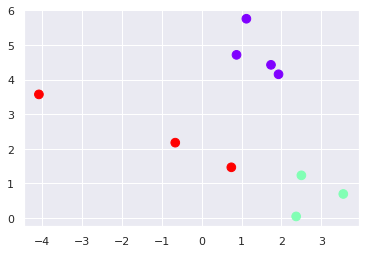

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=75, cmap='rainbow');

### Creating a decision tree

Consider the following two-dimensional data, which has one of four class labels:

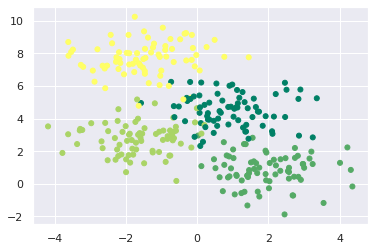

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='summer');

A simple decision tree built on this data will iteratively split the data along one or the other axis according to some quantitative criterion.  At each split, it will assign the label of the new region according to a majority vote of points within it.

The following figure displays a visualization of the first four levels of a decision tree classifier for this data:

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.08-decision-tree-levels.png?raw=1)

Notice that after the first split, every point in the upper branch remains unchanged, so there is no need to further subdivide this branch.
Except for nodes that contain all of one color, at each level **every** region is again split along one of the two features.

This process of fitting a decision tree to our data can be done in Scikit-Learn with the ``DecisionTreeClassifier`` estimator:

In [ ]:
# For a classification problem, we import DecisionTreeClassifier estimator
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

You can run the following Python script to have an interactie visualization of the decision tree building process for this classification problem:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from ipywidgets import interact


def visualize_tree(estimator, X, y, boundaries=True,
                   xlim=None, ylim=None, ax=None):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()
    
    # fit the estimator
    estimator.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    n_classes = len(np.unique(y))
    Z = Z.reshape(xx.shape)
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='viridis',
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    
    # Plot the decision boundaries
    def plot_boundaries(i, xlim, ylim):
        if i >= 0:
            tree = estimator.tree_
        
            if tree.feature[i] == 0:
                ax.plot([tree.threshold[i], tree.threshold[i]], ylim, '-k', zorder=2)
                plot_boundaries(tree.children_left[i],
                                [xlim[0], tree.threshold[i]], ylim)
                plot_boundaries(tree.children_right[i],
                                [tree.threshold[i], xlim[1]], ylim)
        
            elif tree.feature[i] == 1:
                ax.plot(xlim, [tree.threshold[i], tree.threshold[i]], '-k', zorder=2)
                plot_boundaries(tree.children_left[i], xlim,
                                [ylim[0], tree.threshold[i]])
                plot_boundaries(tree.children_right[i], xlim,
                                [tree.threshold[i], ylim[1]])
            
    if boundaries:
        plot_boundaries(0, xlim, ylim)


def plot_tree_interactive(X, y):
    def interactive_tree(depth=5):
        clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
        visualize_tree(clf, X, y)

    return interact(interactive_tree, depth=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])


def randomized_tree_interactive(X, y):
    N = int(0.5 * X.shape[0])
    
    xlim = (X[:, 0].min(), X[:, 0].max())
    ylim = (X[:, 1].min(), X[:, 1].max())
    
    def fit_randomized_tree(random_state=0):
        clf = DecisionTreeClassifier(max_depth=15)
        i = np.arange(len(y))
        rng = np.random.RandomState(random_state)
        rng.shuffle(i)
        visualize_tree(clf, X[i[:N]], y[i[:N]], boundaries=False,
                       xlim=xlim, ylim=ylim)
    
    interact(fit_randomized_tree, random_state=[0, 100, 1000]);

In [ ]:
plot_tree_interactive(X, y)

interactive(children=(Dropdown(description='depth', index=4, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10), value=5)…

<function __main__.plot_tree_interactive.<locals>.interactive_tree>

We notice that as the depth increases, we tend to get very strangely shaped classification regions. For example, at a depth of five, there is a tall and skinny purple region between the green and blue regions. That is, this decision tree, even at only 5 levels of depth, is clearly **overfitting** the data!

### Decision trees and overfitting

Overfitting is a general property of decision trees. In other words, we can easily build a very deep decision tree to fit details of the particular data rather than the overall properties of the distributions they are drawn from.

To illustrate overffitting in a decision tree, let us consider the following example: two decision trees, each is built (trained) on half of the original dataset

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.08-decision-tree-overfitting.png?raw=1)

- the two trees produce consistent results (e.g., in the four corners),
- the two trees give very different classifications (e.g., in the regions between any two clusters) when the classification is less certain

**The key observation:** 

We might come up with a better classification result by using information from **both** of these decision trees!


 The following function will allow you to interactively display the fits of trees trained on a random subset of the data (random 50% of the original dataset):

In [ ]:
randomized_tree_interactive(X, y)

interactive(children=(Dropdown(description='random_state', options=(0, 100, 1000), value=0), Output()), _dom_c…

**Scaling up: moving to building a forest from a small garden**

If using information from two trees improves our classification results, we might use information from **a large number of trees** to improve our results even further!


## Ensembles of Estimators: Random Forests

**Ensembling** is the process of combining several predictive models in order to produce a combined model that is more accurate than any individual model. Given predictions from several models we could:
 - Regression: take the average of the predictions.
 - Classification: take a vote and use the most common prediction.

We note that for ensembling to work well, the models must be **independent**: their predictions are generated using different processes.


**The main idea:** If you have a collection of individually imperfect and independent models, the mistakes will be discarded when you average these models.


**Bagging**
Bagging is an ensemble method. It is a general-purpose procedure for reducing the variance of a machine learning method but is particularly useful for decision trees. It is based on the notion that multiple overfitting estimators can be combined to reduce the effect of this overfitting. Bagging makes use of an ensemble of parallel estimators, each of which overfits the data, and averages the results to find a better classification (or regression).
Bagging is short for **bootstrap aggregation**, the aggregation of bootstrap samples.


A bootstrap sample is a random sample with replacement. It has the same size as the original sample, however, it might duplicate some of the original observations. For example,




In [ ]:
# Bootstrap sampling
import numpy as np
# Set a seed for reproducibility.
np.random.seed(0)

# Create an original sample array of 1 through 10.
nums = np.arange(1, 11)
print("the original sample:", nums)

# Sample that array 10 times with replacement.
print("the bootstrap sample:",np.random.choice(a=nums, size=10, replace=True))


the original sample: [ 1  2  3  4  5  6  7  8  9 10]
the bootstrap sample: [ 6  1  4  4  8 10  4  6  3  5]



#### Bagging for decision trees

- Grow $n>1$ decision trees using $n$ bootstrap samples from the training data.
 - $n$ should be a large enough for errors to be "stabilized"
 - each decision tree is grown deep so that they have low bias/high variance
- Train each decision tree on its bootstrap sample and make predictions.
- Combine the predictions:
 - Take a vote for classification trees.
 - Average the predictions for regression trees.


Bagging increases predictive accuracy by **reducing the variance**! This is similar to how cross-validation reduces the variance associated with train/test split for estimating out-of-sample error by splitting many times an averaging the results.

Bagging classification can be done manually using Scikit-Learn's ``BaggingClassifier`` meta-estimator, as follows:

#### Bagging Classification with Decision Trees in Scikit-Learn (with n=100)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8, random_state=1)


Let's write a quick utility function to help us visualize the output of the classifier:

In [ ]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, 
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

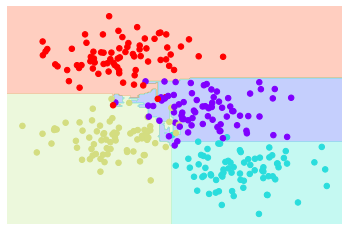

In [ ]:
bag.fit(X, y)
visualize_classifier(bag, X, y)

Notice that in the above example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points.
In practice, decision trees are more effectively randomized by injecting some randomness in how the splits are chosen: this way all the data contributes to the fit each time, but the results of the fit still have the desired randomness.
For example, when determining which feature to split on, the randomized tree might select from among the top several features. In Scikit-Learn, such an optimized ensemble of randomized decision trees is implemented in the ``RandomForestClassifier`` estimator, which takes care of all the randomization automatically. All you need to do is select a number of estimators, and it will very quickly fit the ensemble of decision trees. An ensemble of randomized decision trees is known as a **random forest**:



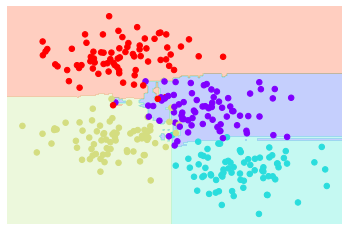

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

It is important to observe that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split!

## Random Forest Regression

We have described how random forests work within the context of classification.
Random forests can also be made to work in the case of regression (that is, continuous rather than categorical variables). The estimator to use for this is the ``RandomForestRegressor`` in Scikit-Learn, and the syntax is very similar to what we saw earlier.

Let us consider the following data, drawn from the combination of a fast and slow oscillation:

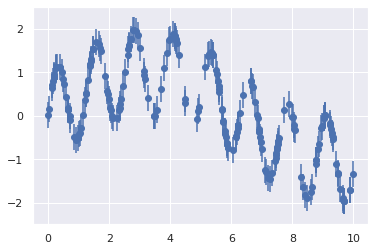

In [ ]:
# set random seed for reproducibility
rng = np.random.RandomState(1)

# create an array of size 200 and populate it with random samples from a uniform distribution over [0, 1) multiplied by 10
x = 10 * rng.rand(200)

# create data drawn from the combination of a fast and slow oscillation
def model(x):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    
    return slow_oscillation + fast_oscillation

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o');

We can use the random forest regressor to find the best fit curve for the above generated data as follows:

In [ ]:
# let us check the shape of generated data x
x.shape

(200,)

In [ ]:
# let us add a psuedo dimension via None keyword to make sure that x has the shape of number of samples by number of features, i.e., (200,1)
x[:, None].shape

(200, 1)

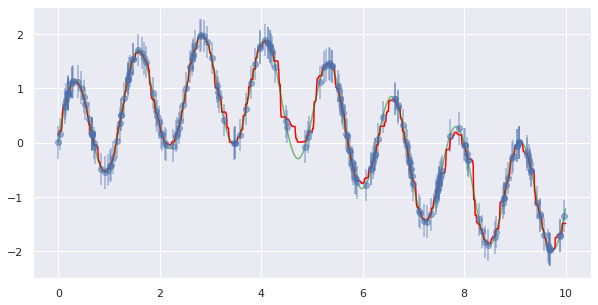

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators = 200)


forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit)

plt.errorbar(x, y, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfit, color = 'red');
plt.plot(xfit, ytrue, alpha=0.5, color = 'green');
plt.gcf().set_size_inches(10, 5) #get current figure with .gcf() method and set its size in inches

In the above plot, the true model is shown in the smooth green curve, while the random forest model is shown by the jagged red curve.
As you can see, the non-parametric random forest model is flexible enough to fit the multi-period data, without us needing to specifying a multi-period model! The power of random forest model!

## Example: Random Forest for Classifying Digits

Previously, we looked into the hand-written digits data when we started looking into the Scikit-Learn library in Python. Let us use a random forest classifier on this dataset:

In [ ]:
# let us lood the data from datasets module in scikit-learn
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()  #here are the following dictionary keys for scikit-learn bunch object digits

dict_keys(['data', 'target', 'target_names', 'images', 'DESCR'])

To remind us what we're looking at, we'll visualize the first few data points:

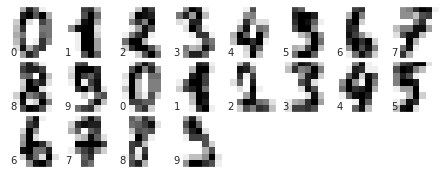

In [ ]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(20):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    
    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

We can quickly classify the digits using a random forest classifier as follows:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# import train_test_split 
from sklearn.model_selection import train_test_split


# split the data into training and test
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, random_state=0)

# instantiate RandomForestClassifier with n = 1000
model = RandomForestClassifier(n_estimators=1000)

# fit the training data to RandomForestClassifier object "model"
model.fit(Xtrain, ytrain)

# produce predictions (i.e., digit labels) for test data
ypred = model.predict(Xtest)

We can take a look at the classification report for the random forest classifier:

In [ ]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.95      0.97        44
           2       0.95      1.00      0.98        42
           3       0.98      0.98      0.98        45
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



Also, we can plot the corresponding confusion matrix:

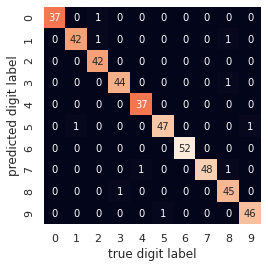

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true digit label')
plt.ylabel('predicted digit label');

It is important to observe that a simple, untuned random forest classifier results in a very accurate classification of the hand-written digits data! 

## Summary of Random Forest

In this lesson, we learned about the concept of **ensemble estimators**, and in particular the **random forest** – an ensemble of randomized decision trees.
Random forest is a powerful machine learning method with several advantages:

- Both training and prediction are very fast, because of the simplicity of the underlying decision trees. 
- The multiple trees allow for a probabilistic classification: a majority vote among estimators gives an estimate of the probability (accessed in Scikit-Learn with the ``predict_proba()`` method).
- The nonparametric model is extremely flexible, and can thus perform well on tasks that are under-fit by other estimators.

A primary disadvantage of a random forest model: 
- the results are not easily interpretable: that is, if you would like to draw conclusions about the *meaning* of the classification model, random forests may not be the best choice.